# 04. Customer Behavior & Loyalty

**Notebook goal:** review behavior basics (distribution, comment presence), the repeat customer story, the voucher payment mini story, and four of the project's discovery pillar findings. The speculative, previously unreported patterns from the interaction effect pass (holiday tolerance, the early delivery ceiling effect, category delay sensitivity, and the repeat customer delay interaction).

**Source:** `analysis_master.csv`, `order_reviews_dataset.csv`.

The four discovery finding charts are marked explicitly as such, since they carry more caveats than the rest of the project's findings and shouldn't be read with the same confidence as, say, the delay review anchor relationship.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

!pip install adjustText
from adjustText import adjust_text

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "font.size": 11,
})
ACCENT = "#2E5EAA"
ACCENT_WARN = "#C0392B"
NEUTRAL = "#B0B0B0"

In [2]:
df = pd.read_csv('analysis_master.csv')
delivered = df[df["is_delivered"] == True].copy()
print(f"Loaded {len(df):,} orders, {len(delivered):,} delivered")

Loaded 99,441 orders, 96,478 delivered


In [3]:
bins = [-200, -7, 0, 3, 7, 999]
labels = ["5+ days early", "on-time/early", "1-3 days late", "4-7 days late", "8+ days late"]
delivered["delay_bucket"] = pd.cut(delivered["delivery_delay_days"], bins=bins, labels=labels)
delivered["is_repeat"] = delivered["customer_order_count"] > 1
print(f"Repeat-customer orders: {delivered['is_repeat'].sum():,} of {len(delivered):,}")

Repeat-customer orders: 6,099 of 96,478


## Review score distribution

The baseline shape everything else in this notebook builds on. Uses all orders with a review, not just delivered ones. A small number of non delivered orders (shipped/canceled) still receive a review in this dataset, usually a critical one, so restricting to delivered only would understate the 1 star share.

In [4]:
reviewed = df[df["review_score"].notna()]
review_dist = reviewed["review_score"].value_counts(normalize=True).sort_index() * 100
review_dist

,proportion
review_score,
1.0,11.518855
2.0,3.171080
3.0,8.242376
4.0,19.300112
5.0,57.767576


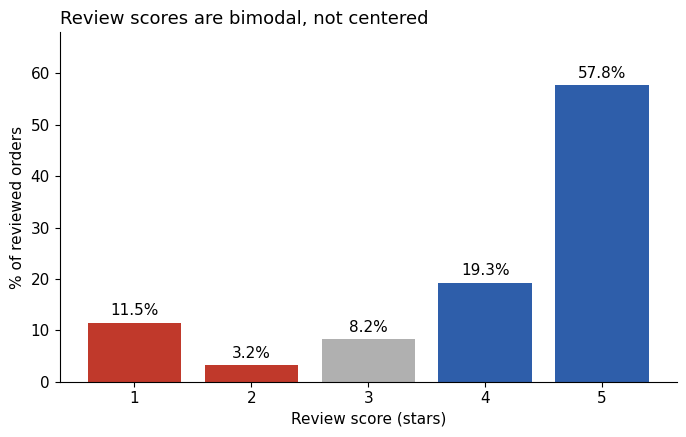

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(review_dist.index.astype(int), review_dist.values,
              color=[ACCENT_WARN if s <= 2 else NEUTRAL if s == 3 else ACCENT for s in review_dist.index])
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_xlabel("Review score (stars)")
ax.set_ylabel("% of reviewed orders")
ax.set_title("Review scores are bimodal, not centered", fontsize=13, loc="left")
ax.set_ylim(0, 68)
plt.tight_layout()
plt.show()

**Finding:** the distribution is bimodal with 57.8% five star, but a real 11.5% one star tail, with the middle (2-3 stars) thin by comparison.

- Customers mostly either love or actively dislike their order; a 3 star average framing would misrepresent what's actually a polarized outcome. This shape recurs (in weaker or stronger form) in every category level breakdown from notebook 3.

## Comment presence as a dissatisfaction signal

In [6]:
comment_review = delivered.groupby("has_comment")["review_score"].agg(mean="mean", n="count")
comment_review.index = ["No comment", "Has comment"]
comment_review

,mean,n
No comment,4.413684,55233
Has comment,3.805020,40599


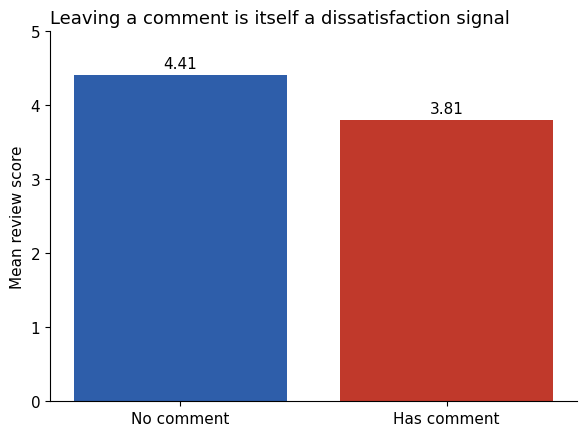

In [7]:
fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(comment_review.index, comment_review["mean"], color=[ACCENT, ACCENT_WARN])
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.set_ylabel("Mean review score")
ax.set_title("Leaving a comment is itself a dissatisfaction signal", fontsize=13, loc="left")
ax.set_ylim(0, 5)
plt.tight_layout()
plt.show()

**Finding:** orders with a comment average 3.81, versus 4.41 without one, a 0.6 point gap, larger than most delay bucket transitions from notebook 01.

- A cheap, strong proxy for dissatisfaction that's available immediately, without needing to process the (mostly Portuguese, largely unprocessed) comment text itself.

## Beyond presence: does comment length say more than just having one?

The chart above only checked whether a comment exists. `order_reviews_dataset.csv` (not part of `analysis_master.csv`) has the actual comment text, which lets us check length too, a cheap signal that doesn't require actually processing the (mostly Portuguese) content.

In [9]:
reviews_raw = pd.read_csv("order_reviews_dataset.csv")
reviews_raw["comment_length"] = reviews_raw["review_comment_message"].fillna("").str.len()

reviews_raw["review_answer_timestamp"] = pd.to_datetime(reviews_raw["review_answer_timestamp"])
reviews_dedup = reviews_raw.sort_values("review_answer_timestamp").drop_duplicates(subset="order_id", keep="last")

length_by_score = reviews_dedup.groupby("review_score")["comment_length"].mean()
length_by_score

,comment_length
review_score,
1,76.570096
2,65.961993
3,36.186032
4,19.294359
5,18.596671


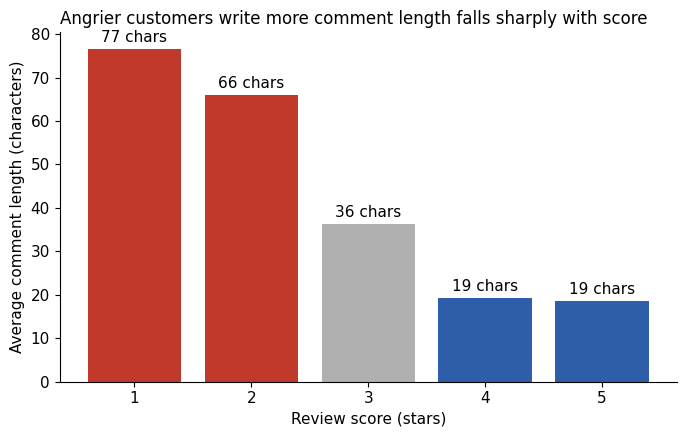

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = [ACCENT_WARN if s <= 2 else NEUTRAL if s == 3 else ACCENT for s in length_by_score.index]
bars = ax.bar(length_by_score.index.astype(int), length_by_score.values, color=colors)
ax.bar_label(bars, fmt="%.0f chars", padding=3)
ax.set_xlabel("Review score (stars)")
ax.set_ylabel("Average comment length (characters)")
ax.set_title("Angrier customers write more comment length falls sharply with score", fontsize=12, loc="left")
plt.tight_layout()
plt.show()

**Finding:** 1 star comments average 76.5 characters which is more than 4x longer than 5 star comments (18.6 characters) and the relationship is cleanly monotonic across all five scores.

- This adds a genuinely new dimension beyond the existing has comment finding: it's not just whether a customer comments, but how much they write, that scales with dissatisfaction.

- A length threshold (e.g. comments over 50 characters) could work as a cheap triage signal for customer service to prioritize, without needing any actual text/sentiment processing.

## Repeat customers and their first-order delivery experience

In [12]:
repeat_delivery = delivered.groupby("is_repeat")["is_late"].agg(mean="mean", n="count")
repeat_delivery.index = ["One time customers", "Repeat customers"]
repeat_delivery["mean"] = repeat_delivery["mean"] * 100
repeat_delivery

,mean,n
One time customers,8.184423,90379
Repeat customers,7.033940,6099


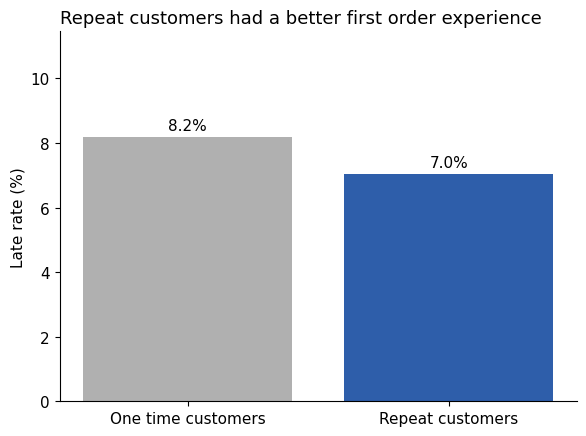

In [13]:
fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(repeat_delivery.index, repeat_delivery["mean"], color=[NEUTRAL, ACCENT])
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_ylabel("Late rate (%)")
ax.set_title("Repeat customers had a better first order experience", fontsize=13, loc="left")
ax.set_ylim(0, repeat_delivery["mean"].max() * 1.4)
plt.tight_layout()
plt.show()

**Finding:** customers who went on to become repeat buyers had a lower late rate on their first order (7.0% vs. 8.2%) than customers who never returned.

- Real and directionally consistent with better delivery means more repeat business, though modest in size, and only 6.3% of customers ever place a second order overall, this is supporting evidence, not the dominant explanation for repeat purchasing.

## How many times do repeat customers actually come back?

Repeat customer so far has been a yes/no flag. Among the customers who do return, how far does that loyalty typically go?

In [14]:
customers = df.dropna(subset=["customer_unique_id"]).drop_duplicates(subset="customer_unique_id")
repeat_counts = customers[customers["customer_order_count"] > 1]["customer_order_count"].value_counts().sort_index()
repeat_counts

,count
customer_order_count,
2,2745
3,203
4,30
5,8
6,6
7,3
9,1
17,1


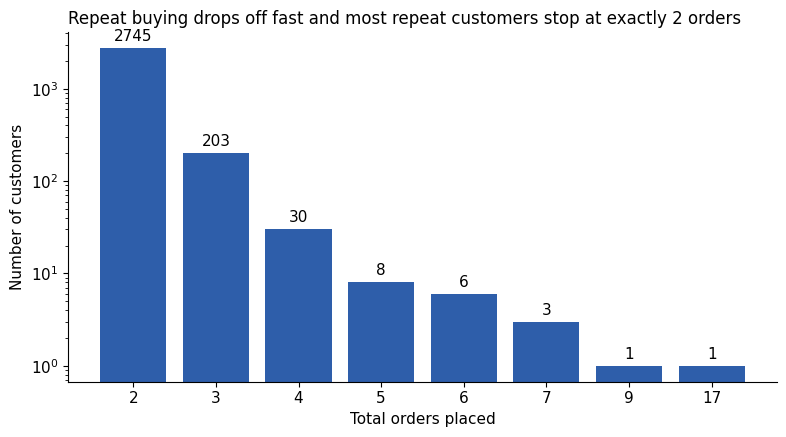

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(repeat_counts.index.astype(str), repeat_counts.values, color=ACCENT)
ax.bar_label(bars, padding=3)
ax.set_xlabel("Total orders placed")
ax.set_ylabel("Number of customers")
ax.set_yscale("log")
ax.set_title("Repeat buying drops off fast and most repeat customers stop at exactly 2 orders", fontsize=12, loc="left")
plt.tight_layout()
plt.show()

**Finding:** 2,745 of the 2,997 repeat customers (91.6%) stop at exactly two orders and true repeat loyalty beyond a second purchase is rare (203 customers at three orders, dropping to single digits beyond that).

- A log scale is used since the drop off spans nearly three orders of magnitude.

- Practical implication: most of the repeat customer story in this project is really a second order story. Any loyalty program recommendation in the final report should be scoped around converting a first time buyer into a second time buyer specifically, since that's where almost all of the actual movement happens.

## The voucher mini story: three tracks' threads brought together

Track A found voucher payments cancel at 5 to 6x the rate of other payment types but couldn't fully explain why. Bringing cancellation rate, order value, and review score together in one view builds the different customer profile case Track A and D each partly supported.

In [16]:
payment_summary = df.groupby("payment_type_primary").agg(
    cancel_rate=("is_canceled", "mean"),
    avg_order_value=("total_payment_value", "mean"),
    n=("order_id", "count"),
)
payment_review = df[df["review_score"].notna()].groupby("payment_type_primary")["review_score"].mean()
payment_summary["avg_review"] = payment_review
payment_summary = payment_summary.drop("not_defined")  # only 3 orders, not a real payment method
payment_summary["cancel_rate"] = payment_summary["cancel_rate"] * 100
payment_summary

,cancel_rate,avg_order_value,n,avg_review
payment_type_primary,,,,
boleto,0.480186,145.034435,19784,4.086830
credit_card,0.576192,167.289458,74975,4.087995
debit_card,0.458415,142.724158,1527,4.168968
voucher,2.792764,120.293212,3151,4.004486


/tmp/ipykernel_1500/3455503878.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=30, ha="right")
/tmp/ipykernel_1500/3455503878.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=30, ha="right")
/tmp/ipykernel_1500/3455503878.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=30, ha="right")


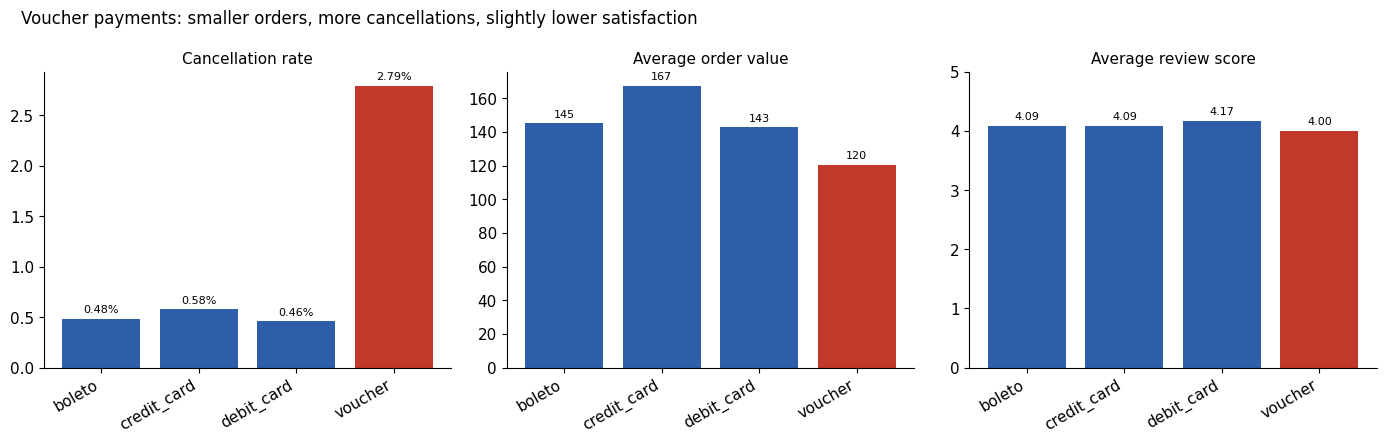

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
methods = payment_summary.index
colors = [ACCENT_WARN if m == "voucher" else ACCENT for m in methods]

axes[0].bar(methods, payment_summary["cancel_rate"], color=colors)
axes[0].bar_label(axes[0].containers[0], fmt="%.2f%%", padding=3, fontsize=8)
axes[0].set_title("Cancellation rate", fontsize=11)

axes[1].bar(methods, payment_summary["avg_order_value"], color=colors)
axes[1].bar_label(axes[1].containers[0], fmt="%.0f", padding=3, fontsize=8)
axes[1].set_title("Average order value", fontsize=11)

axes[2].bar(methods, payment_summary["avg_review"], color=colors)
axes[2].bar_label(axes[2].containers[0], fmt="%.2f", padding=3, fontsize=8)
axes[2].set_title("Average review score", fontsize=11)
axes[2].set_ylim(0, 5)

for ax in axes:
    ax.set_xticklabels(methods, rotation=30, ha="right")

fig.suptitle("Voucher payments: smaller orders, more cancellations, slightly lower satisfaction", fontsize=12, x=0.02, ha="left")
plt.tight_layout()
plt.show()

**Finding:** voucher orders are notably smaller on average (120 real vs. 167 real for credit card), cancel far more often (2.8% vs. 0.5%), and score slightly lower on reviews (4.00 vs. 4.09).

- All three point the same direction, adding weight to the different, more price sensitive customer segment explanation over voucher redemption technically fails more often. Though this remains a plausible read of correlated evidence, not a confirmed mechanism. No new data source exists in this project to fully settle it.

## Discovery finding: no holiday tolerance effect

**Caveat upfront:** this bucket by calendar month approach is a proxy for high demand period, not real promotional calendar data so treat the direction as a real, checked pattern, but the exact size with some caution.

Does the delay review relationship weaken during the Nov 2017 Jan 2018 period, when customers might reasonably expect more strain on the system?

In [18]:
holiday_months = ["2017-11", "2017-12", "2018-01"]
delivered["is_holiday_period"] = delivered["purchase_month"].isin(holiday_months)

holiday_table = (delivered.groupby(["delay_bucket", "is_holiday_period"], observed=True)["review_score"]
                  .agg(mean="mean", n="count").unstack("is_holiday_period"))
holiday_table

mean                n       
is_holiday_period     False     True   False  True 
delay_bucket                                       
5+ days early      4.325391  4.284051  56157  14772
on-time/early      4.232478  4.047856  14225   3009
1-3 days late      3.835300  3.531561   2034    602
4-7 days late      2.344725  2.234192   1346    427
8+ days late       1.766908  1.622642   2351    901

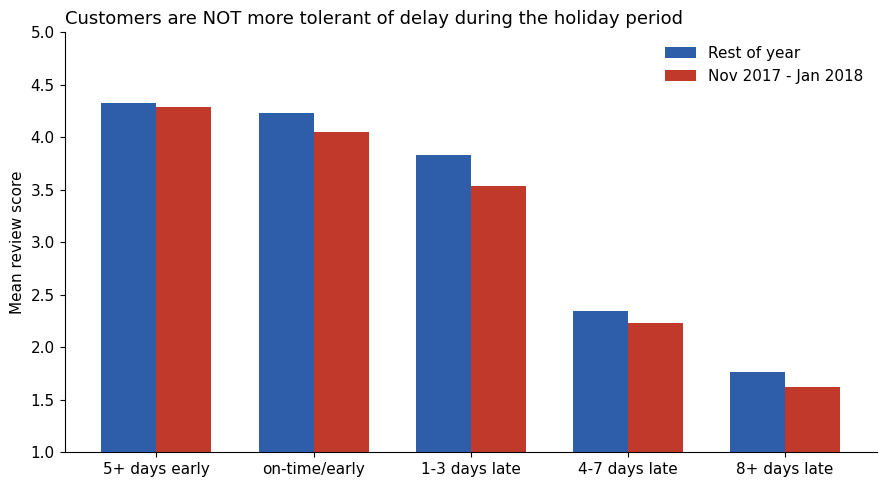

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(labels))
width = 0.35

means_normal = [holiday_table.loc[l, ("mean", False)] for l in labels]
means_holiday = [holiday_table.loc[l, ("mean", True)] for l in labels]

ax.bar(x - width/2, means_normal, width, label="Rest of year", color=ACCENT)
ax.bar(x + width/2, means_holiday, width, label="Nov 2017 - Jan 2018", color=ACCENT_WARN)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Mean review score")
ax.set_title("Customers are NOT more tolerant of delay during the holiday period", fontsize=13, loc="left")
ax.legend(frameon=False)
ax.set_ylim(1, 5)
plt.tight_layout()
plt.show()

**Finding:** at every single delay bucket, the holiday period bar sits below the rest of year bar which is the opposite of customers understand the rush.

- The gap is modest (0.05 to 0.30 points depending on bucket) but consistent in direction across all five buckets, which is more convincing than any single gap alone.

- Speculative on mechanism: possibly holiday period customers have higher expectations (gifts, deadlines) rather than more slack ones.

## Discovery finding: an early delivery ceiling effect

Does satisfaction keep rising the earlier an order arrives, or is there a point where more early stops helping?

In [20]:
delivered["early_days"] = -delivered["delivery_delay_days"]
fine_bins = [0, 3, 7, 14, 21, 30, 45, 999]
fine_labels = ["1-3d early", "4-7d early", "8-14d early", "15-21d early", "22-30d early", "31-45d early", "45+d early"]
delivered["fine_early_bucket"] = pd.cut(delivered["early_days"], bins=fine_bins, labels=fine_labels)

ceiling = delivered[delivered["early_days"] > 0].groupby("fine_early_bucket", observed=True)["review_score"].agg(mean="mean", n="count")
ceiling

,mean,n
fine_early_bucket,,
1-3d early,4.133262,4705
4-7d early,4.225397,12529
8-14d early,4.310609,36158
15-21d early,4.341320,24165
22-30d early,4.289515,8269
31-45d early,4.250835,2097
45+d early,4.291667,240


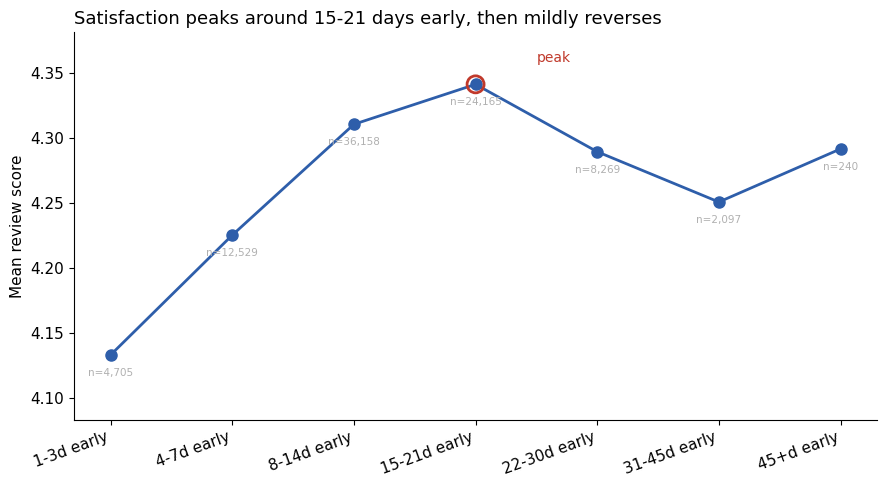

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(ceiling))
ax.plot(x_pos, ceiling["mean"], marker="o", markersize=8, linewidth=2, color=ACCENT)

peak_idx = ceiling["mean"].values.argmax()
peak_val = ceiling["mean"].iloc[peak_idx]
ax.scatter([peak_idx], [peak_val], s=150, facecolors="none", edgecolors=ACCENT_WARN, linewidth=2, zorder=5)
ax.annotate("peak", xy=(peak_idx, peak_val), xytext=(peak_idx + 0.5, peak_val + 0.015),
            ha="left", va="bottom", color=ACCENT_WARN, fontsize=10)

y_min, y_max = ceiling["mean"].min(), ceiling["mean"].max()
ax.set_ylim(y_min - 0.05, y_max + 0.04)

for x, (mean, n) in zip(x_pos, zip(ceiling["mean"], ceiling["n"])):
    ax.text(x, mean - 0.01, f"n={n:,}", ha="center", va="top", fontsize=7.5, color=NEUTRAL)

ax.set_xticks(x_pos)
ax.set_xticklabels(ceiling.index, rotation=20, ha="right")
ax.set_ylabel("Mean review score")
ax.set_title("Satisfaction peaks around 15-21 days early, then mildly reverses", fontsize=13, loc="left")
plt.tight_layout()
plt.show()

**Finding:** review score rises with earliness up to the 15 to 21 day early bucket (peak 4.34), then declines slightly through 22 to 45 days early (down to 4.25) before an uptick in the tiny 45+ bucket (n = 240, too small to read confidently).

- Earlier is always better isn't quite right. The 31 to 45 day bucket's sample (n = 2,097) is solid enough to trust the reversal itself; the very last point is not.

- Speculative on mechanism: possibly extremely early delivery feels less cared for, or correlates with some other unmeasured factor (e.g. simpler/lighter items that ship fast by nature).

## Discovery finding: delay sensitivity tracks semantic urgency

Does every category react to delay the same way, or do some categories care more?

In [23]:
top10_cats = delivered["primary_category"].value_counts().head(10).index
cat_sensitivity = pd.Series({
    cat: delivered[delivered["primary_category"] == cat]["delivery_delay_days"].corr(
         delivered[delivered["primary_category"] == cat]["review_score"])
    for cat in top10_cats
}).sort_values()
cat_sensitivity

,0
toys,-0.332431
sports_leisure,-0.311950
health_beauty,-0.306688
telephony,-0.269526
watches_gifts,-0.268583
computers_accessories,-0.254241
auto,-0.253531
bed_bath_table,-0.248673
furniture_decor,-0.219998
housewares,-0.219580


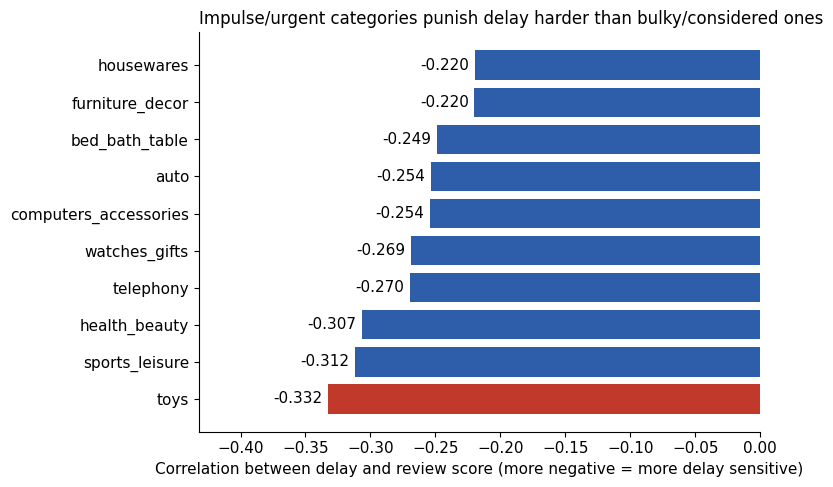

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(cat_sensitivity))
colors = [ACCENT_WARN if v == cat_sensitivity.min() else ACCENT for v in cat_sensitivity.values]
bars = ax.barh(y_pos, cat_sensitivity.values, color=colors)
ax.bar_label(bars, fmt="%.3f", padding=4)
ax.set_yticks(y_pos)
ax.set_yticklabels(cat_sensitivity.index)
ax.set_xlim(cat_sensitivity.min() * 1.3, 0)
ax.set_xlabel("Correlation between delay and review score (more negative = more delay sensitive)")
ax.set_title("Impulse/urgent categories punish delay harder than bulky/considered ones", fontsize=12, loc="left")
plt.tight_layout()
plt.show()

**Finding:** `toys`, `sports_leisure`, and `health_beauty` are the most delay sensitive (correlation around -0.31), while `furniture_decor` and `housewares` are the least (-0.22) which is a real, moderate spread.

- Speculative but possible reading: toys and gifts often carry a specific occasion or urgency (a birthday, a planned activity), while furniture and housewares purchases are typically planned well in advance with more schedule slack built in already.

- Worth testing against actual purchase occasion data if that ever becomes available. Though this project has no direct way to confirm the why, only the occurance.

## Discovery finding: loyalty buys patience for big failures, not small slips

Notebook 01 and this notebook both show repeat customers do somewhat better on average. Does that more forgiving story hold the same way at every delay level?

In [25]:
repeat_interaction = (delivered.groupby(["delay_bucket", "is_repeat"], observed=True)["review_score"]
                       .agg(mean="mean", n="count").unstack("is_repeat"))
repeat_interaction

mean                n      
is_repeat         False     True   False True 
delay_bucket                                  
5+ days early  4.315820  4.330468  66275  4654
on-time/early  4.200591  4.194473  16257   977
1-3 days late  3.774518  3.621622   2488   148
4-7 days late  2.297683  2.700000   1683    90
8+ days late   1.716981  1.898876   3074   178

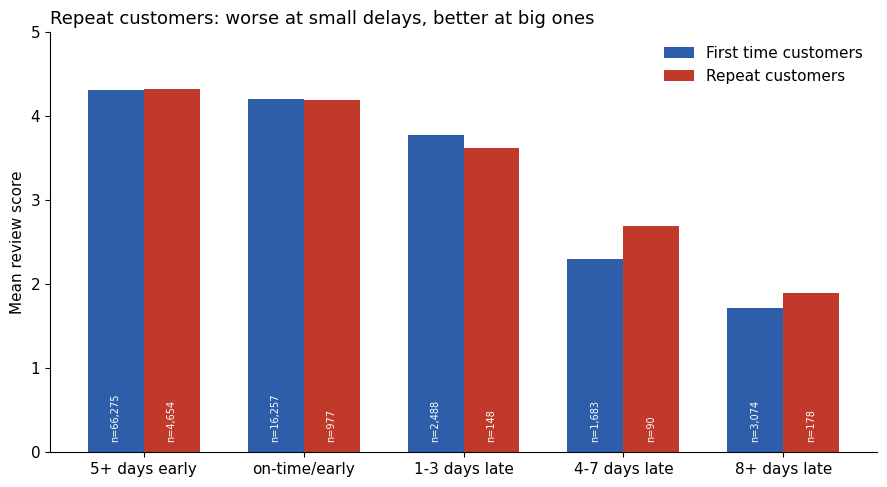

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(labels))
width = 0.35

means_first = [repeat_interaction.loc[l, ("mean", False)] for l in labels]
means_repeat = [repeat_interaction.loc[l, ("mean", True)] for l in labels]
n_first = [repeat_interaction.loc[l, ("n", False)] for l in labels]
n_repeat = [repeat_interaction.loc[l, ("n", True)] for l in labels]

bars1 = ax.bar(x - width/2, means_first, width, label="First time customers", color=ACCENT)
bars2 = ax.bar(x + width/2, means_repeat, width, label="Repeat customers", color=ACCENT_WARN)

for bar, n in zip(bars1, n_first):
    ax.text(bar.get_x() + bar.get_width()/2, 0.15, f"n={n:,}", ha="center", fontsize=7, rotation=90, color="white")
for bar, n in zip(bars2, n_repeat):
    ax.text(bar.get_x() + bar.get_width()/2, 0.15, f"n={n:,}", ha="center", fontsize=7, rotation=90, color="white")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Mean review score")
ax.set_title("Repeat customers: worse at small delays, better at big ones", fontsize=13, loc="left")
ax.legend(frameon=False)
ax.set_ylim(0, 5)
plt.tight_layout()
plt.show()

**Finding:** at 1 to 3 days late, repeat customers actually score lower than first timers (3.62 vs. 3.78) but at 4 to 7 days late (2.70 vs. 2.30) and 8+ days late (1.90 vs. 1.72), they score higher.

- Loyalty seems to buy forgiveness specifically for genuine failures, not minor slips which is a more nuanced story than a flat repeat customers are more forgiving.

- Note on sample size: the repeat customer late buckets are thin (n = 90 to n = 178) compared to tens of thousands for first time customers so the direction is consistent enough across both late buckets to take seriously, but this is directional evidence, not a precise estimate.

## Summary

1. Review scores are genuinely bimodal: most orders are loved or actively disliked, few sit in the middle.
2. Comment presence is a strong, cheap dissatisfaction proxy (0.6 point gap).
3. Repeat customers had modestly better first order delivery experiences.
4. The voucher cancellation puzzle from Track A gets three consistent, mutually reinforcing pieces of evidence (smaller orders, more cancellations, lower reviews) without being fully resolved.
5. Four discovery pillar findings, all previously unreported: no holiday leniency (customers are if anything slightly less tolerant), an early delivery ceiling effect, category level delay sensitivity tracking plausible semantic urgency, and a repeat customer interaction that only kicks in for large delays.